# Results Visualization

In this notebook we load the held-out **test** split, run the trained
`SquigNet` model on a single example, and visualize both the standardized
signal and the predicted base calls, along with accuracy.

In [1]:
from __future__ import annotations

import pickle
import sys
from pathlib import Path
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import torch

# Ensure src/ is on sys.path
ROOT = Path("..").resolve()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from architecture import SquigNet  # type: ignore
from inference import (  # type: ignore
    load_model,
    run_inference,
    greedy_decode,
    calculate_accuracy,
)

In [2]:
"""Load first test example from data/test and run SquigNet inference."""

test_dir = ROOT / "data" / "test"
signals_path = test_dir / "signals.pt"
sequences_path = test_dir / "sequences.pkl"

if not signals_path.exists() or not sequences_path.exists():
    raise FileNotFoundError(
        "Test data not found. Run `python src/data_simulator.py` first "
        "to generate data/train and data/test."
    )

signals: List[np.ndarray] = torch.load(signals_path, weights_only=False)
with open(sequences_path, "rb") as f:
    sequences: List[str] = pickle.load(f)

signal = signals[0]
target_sequence = sequences[0]

print(f"Loaded 1 test example from {test_dir}")
print(f"  Signal length: {len(signal)} samples")
print(f"  Target length: {len(target_sequence)} bases")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model(ROOT / "models" / "squig_model.pt", device=device)

logits = run_inference(model, signal, device=device)
predicted_sequence = greedy_decode(logits)
accuracy = calculate_accuracy(predicted_sequence, target_sequence)

print("\nTarget DNA:   ", target_sequence)
print("Predicted DNA:", predicted_sequence)
print(f"\nAccuracy: {accuracy:.2%}")

Loaded 1 test example from /Users/janetx/Desktop/Janet/Projects/SquigDecode/data/test
  Signal length: 797 samples
  Target length: 57 bases

Target DNA:    TGGCAAGACAGGGTGACTGAATGATTAATAAACGGCTTTAGCAATTTGAACAAGCCT
Predicted DNA: TGGCAAGACAGGGTGACTGAATGGATTAATAACGGCTTAGCATTTGAACAAGCCT

Accuracy: 94.74%


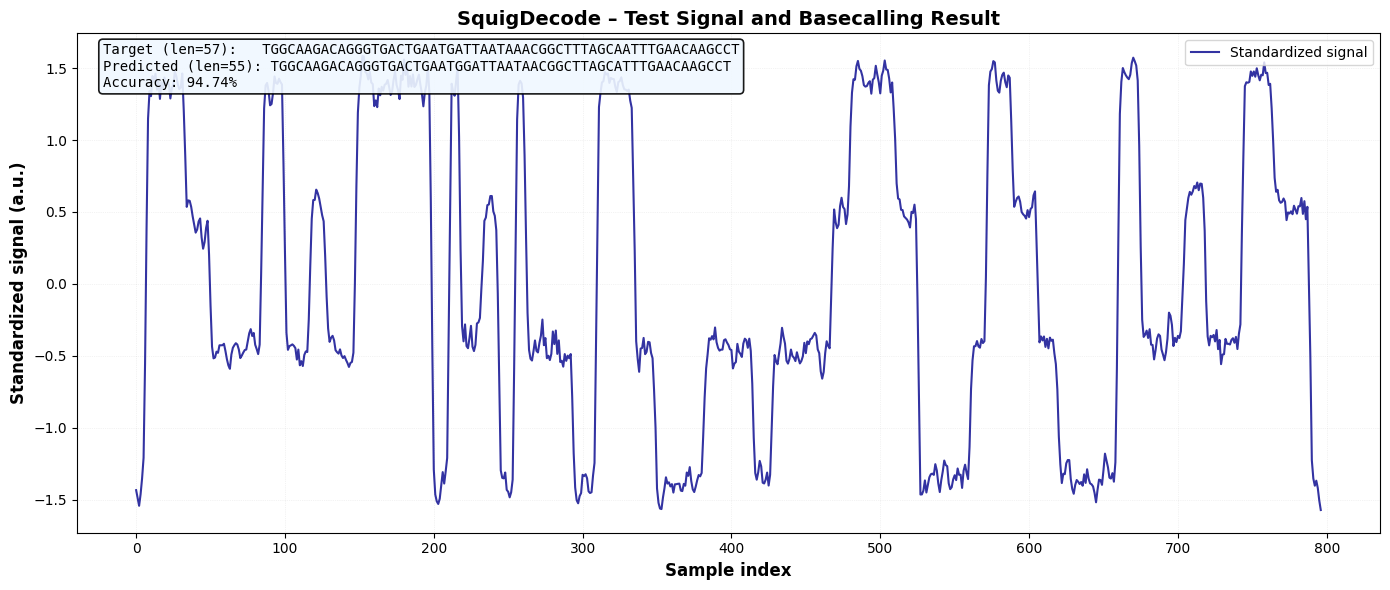

In [3]:
"""Plot the standardized test signal and display prediction summary."""

fig, ax = plt.subplots(figsize=(14, 6))

sample_indices = np.arange(len(signal))
ax.plot(
    sample_indices,
    signal,
    linewidth=1.5,
    color="darkblue",
    alpha=0.8,
    label="Standardized signal",
)

ax.set_xlabel("Sample index", fontsize=12, fontweight="bold")
ax.set_ylabel("Standardized signal (a.u.)", fontsize=12, fontweight="bold")
ax.set_title(
    "SquigDecode – Test Signal and Basecalling Result",
    fontsize=14,
    fontweight="bold",
)
ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.5)
ax.legend(loc="upper right", fontsize=10)

info_text = (
    f"Target (len={len(target_sequence)}):   {target_sequence}\n"
    f"Predicted (len={len(predicted_sequence)}): {predicted_sequence}\n"
    f"Accuracy: {accuracy:.2%}"
)

ax.text(
    0.02,
    0.98,
    info_text,
    transform=ax.transAxes,
    fontsize=10,
    fontfamily="monospace",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="#F0F8FF",
        alpha=0.9,
        edgecolor="black",
        linewidth=1.2,
    ),
)

plt.tight_layout()
plt.show()